# 02 - Windows, labels, and what the features contain

Notebook 01 looked at jobs. This one turns each job's telemetry into the rows a
model would actually be trained on, and then asks what those rows contain.

**The window strategy**

A *window* is `WINDOW = 40` consecutive snapshots from one `(job, node)` series.
At the 30 s cadence verified in notebook 01 that is exactly 20 minutes of
history. Each window is summarised by four aggregations -- min, max, mean and
standard deviation -- of every metric, and that summary is one row.

Three rules make the window meaningful:

1. **One job, one node.** A job that spans several nodes is split into one series
   per node. A window never mixes two machines.
2. **No windowing across a gap.** If any interval inside the 40 snapshots is
   longer than `GAP_TOL_S = 60 s`, the window is discarded: a mean over telemetry
   an hour apart is not a 20-minute summary. Notebook 01 showed this costs about
   0.005 % of intervals.
3. **Stride.** Consecutive windows overlap in 39 of 40 snapshots, so they are
   almost the same row. We keep every `STRIDE = 10`-th start, which is enough for
   a descriptive study and keeps the file small.

**The label**

A *snapshot* is positive when its job ends in one of the four failure states
**and** the snapshot falls within `HORIZON_H = 2 h` of that end. A *window* is
positive when at least half of its 40 snapshots are -- a majority vote.

What we deliberately do **not** do is collapse a job into a single row. The unit
of prediction is a 20-minute window during a running job, because the point is to
warn while the job is still alive.

In [1]:
# --- Setup: paths, constants, plotting -------------------------------------
# This block is repeated verbatim at the top of all three notebooks so that each
# one can be read and run on its own. The notebooks share *data* (the parquet
# files written into data/), never code.
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW    = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
HWINFO = ROOT / "dataset" / "node_hardware_info.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# --- Pipeline constants ----------------------------------------------------
WINDOW     = 40     # snapshots per window -> 20 minutes at a 30 s cadence
HORIZON_H  = 2.0    # a snapshot is positive within 2 h of a failing job's end
GAP_TOL_S  = 60.0   # reject any window that contains a larger gap than this
STRIDE     = 10     # keep every 10th window start inside a series
TRAIN_FRAC = 0.8    # temporal split: the first 80 % of jobs by end_date
SNAP_S     = 30.0   # telemetry cadence -- verified in step 6 below

# "OOM" always denotes the OUT_OF_MEMORY *job state*, never a machine that ran
# out of RAM.
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})

def save(fig, name):
    """Write a figure into figures/ and return it so the cell still displays it."""
    fig.savefig(FIGS / name, bbox_inches="tight")
    return fig

print("dataset:", RAW, "|", "found" if RAW.exists() else "MISSING")

dataset: D:\_fcall\UNIFEI\tcc\hpc_workload\dataset\prom_slurm_joined\prom_slurm_joined.parquet | found


In [2]:
# --- The metrics carried into the windowing step ---------------------------
# Chosen in notebook 01 step 11 from the columns that are neither constant nor
# very coarse, and spread across four subsystems so the box plots below compare
# unlike things rather than fourteen views of the same thing.
RAW_METRICS = {                                   # metric name -> parquet column
    "gpu_temp_mean":  "nvidia_gpu_temperature_celsius_mean",
    "gpu_power_mean": "nvidia_gpu_power_usage_milliwatts_mean",
    "gpu_duty_mean":  "nvidia_gpu_duty_cycle_mean",
    "gpu_mem_used":   "nvidia_gpu_memory_used_bytes_sum",
    "gpu_fan_mean":   "nvidia_gpu_fanspeed_percent_mean",
    "mem_free":       "node_memory_MemFree_bytes",
    "mem_active":     "node_memory_Active_bytes",
    "mem_dirty":      "node_memory_Dirty_bytes",
    "load1":          "node_load1",
    "procs_running":  "node_procs_running",
    "procs_blocked":  "node_procs_blocked",
    "node_power":     "node_power_usage",
}
# Cumulative counters: the raw value mostly encodes how long the node has been
# up, so we difference them into a per-second rate before windowing.
CUM_METRICS = {
    "disk_written_rate": "node_disk_written_bytes_total_sum",
    "net_rx_rate":       "node_network_receive_bytes_total_sum",
}
METRICS = list(RAW_METRICS) + list(CUM_METRICS)
AGGS = ["min", "max", "mean", "std"]
FEATURES = [f"{m}__{a}" for m in METRICS for a in AGGS]
GROUP = ({m: "gpu" for m in RAW_METRICS if m.startswith("gpu")}
         | {m: "memory" for m in ("mem_free", "mem_active", "mem_dirty")}
         | {m: "load" for m in ("load1", "procs_running", "procs_blocked", "node_power")}
         | {m: "io" for m in CUM_METRICS})
print(f"{len(METRICS)} metrics x {len(AGGS)} aggregations = {len(FEATURES)} features")

14 metrics x 4 aggregations = 56 features


## 1. What a window looks like, on a real job

Before building millions of them, one picture. We take a real TIMEOUT job and a
real OUT_OF_MEMORY job, plot two metrics across their lifetime, shade the last
two hours (the horizon) and draw two windows: one early in the job, which is
labelled 0, and one inside the horizon, which is labelled 1.

In [3]:
jobs = pd.read_parquet(DATA / "jobs.parquet")

def pick(state, lo_h, hi_h):
    """First job (by id, so the choice is deterministic) in a runtime band."""
    c = jobs[(jobs.state == state) & (jobs.slurm_h.between(lo_h, hi_h))
             & (jobs.n_nodes_seen == 1)]
    return int(c.sort_values("slurm_id").slurm_id.iloc[0])

examples = {"TIMEOUT": pick("TIMEOUT", 3, 6), "OUT_OF_MEMORY": pick("OUT_OF_MEMORY", 2, 6)}
print("example jobs:", examples)

want = list(examples.values())
cols = ["slurm_id", "timestamp", "state", "end_date",
        RAW_METRICS["gpu_mem_used"], RAW_METRICS["gpu_duty_mean"]]
chunks = []
for p in sorted(RAW.glob("part-*.parquet")):
    t = pq.read_table(p, columns=cols + ["gpu_node"])
    t = t.filter(pc.is_in(pc.field("slurm_id"), pa.array(want)))
    if t.num_rows:
        chunks.append(t.drop_columns(["gpu_node"]))
ex = pa.concat_tables(chunks).to_pandas().sort_values(["slurm_id", "timestamp"])
print(f"{len(ex):,} snapshots for the two example jobs")

example jobs: {'TIMEOUT': 1916906, 'OUT_OF_MEMORY': 1920341}


919 snapshots for the two example jobs


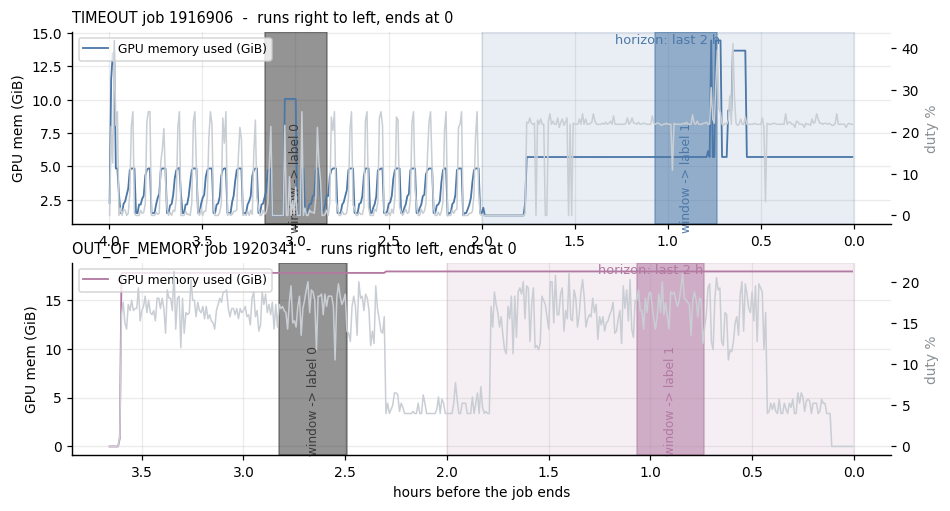

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.0))
for ax, (state, jid) in zip(axes, examples.items()):
    d = ex[ex.slurm_id == jid]
    hrs = (d.end_date.iloc[0] - d.timestamp).dt.total_seconds() / 3600   # time TO end
    gb = d[RAW_METRICS["gpu_mem_used"]] / 2**30
    ax.plot(hrs, gb, color=COLOR[state], lw=1.2, label="GPU memory used (GiB)")
    ax2 = ax.twinx()
    ax2.plot(hrs, d[RAW_METRICS["gpu_duty_mean"]], color="#c9ced4", lw=1.0, zorder=0,
             label="GPU duty cycle (%)")
    ax2.set_ylabel("duty %", color="#8a8f94"); ax2.grid(False)

    ax.axvspan(0, HORIZON_H, color=COLOR[state], alpha=0.12)
    ax.text(HORIZON_H * 0.5, ax.get_ylim()[1] * 0.94, f"horizon: last {HORIZON_H:.0f} h",
            ha="center", fontsize=8.5, color=COLOR[state])

    win_h = WINDOW * SNAP_S / 3600
    for centre, lab, col in ((hrs.max() - 1.0, "window -> label 0", "#3c3c3c"),
                             (HORIZON_H * 0.45, "window -> label 1", COLOR[state])):
        ax.axvspan(centre - win_h / 2, centre + win_h / 2, color=col, alpha=0.55)
        ax.annotate(lab, xy=(centre, ax.get_ylim()[1] * 0.55), fontsize=8, ha="center",
                    color=col, rotation=90, va="top")

    ax.invert_xaxis()
    ax.set_ylabel("GPU mem (GiB)")
    ax.set_title(f"{state} job {jid}  -  runs right to left, ends at 0",
                 loc="left", fontsize=9.5)
    ax.legend(fontsize=8, loc="upper left")
axes[-1].set_xlabel("hours before the job ends")
save(fig, "09_window_diagram.png"); plt.show()

The windows are 20 minutes wide, which at this scale is a thin band -- that in
itself is worth seeing. A model gets 20 minutes of history and must decide
whether the job is inside its final two hours.

## 2. Building every window

One streaming pass. The metric columns are pulled straight from Arrow into a
single `float32` array rather than through pandas, which keeps peak memory near
2.5 GB instead of 6 GB.

The window mechanics are vectorised over the whole sorted table with
`sliding_window_view`, so there is no Python loop over jobs:

- a candidate start is valid when its 40th snapshot belongs to the same series;
- and when the largest interval inside those 40 snapshots is at most `GAP_TOL_S`;
- and when its position inside the series is a multiple of `STRIDE`.

In [5]:
t0 = time.time()
KEY_COLS = ["slurm_id", "node", "timestamp", "state", "end_date", "nodetypes", "numnodes"]
SRC = list(RAW_METRICS.values()) + list(CUM_METRICS.values())

tabs = []
for p in sorted(RAW.glob("part-*.parquet")):
    t = pq.read_table(p, columns=KEY_COLS + SRC + ["gpu_node"])
    t = t.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED"))
    if t.num_rows:
        # float32 halves the footprint and is the precision the features are stored in
        t = t.drop_columns(["gpu_node"])
        t = t.cast(pa.schema([f.with_type(pa.float32()) if pa.types.is_floating(f.type)
                              else f for f in t.schema]))
        tabs.append(t)
tab = pa.concat_tables(tabs); del tabs; gc.collect()

keys = tab.select(KEY_COLS).to_pandas()
for c in ("node", "state", "nodetypes"):
    keys[c] = keys[c].astype("category")
order = np.lexsort((keys.timestamp.to_numpy(), keys.node.cat.codes.to_numpy(),
                    keys.slurm_id.to_numpy()))
keys = keys.iloc[order].reset_index(drop=True)

N = len(keys)
vals = np.empty((N, len(METRICS)), dtype=np.float32)
for j, m in enumerate(RAW_METRICS):
    vals[:, j] = tab.column(RAW_METRICS[m]).to_numpy(zero_copy_only=False)[order]
cum = {m: tab.column(src).to_numpy(zero_copy_only=False)[order].astype(np.float64)
       for m, src in CUM_METRICS.items()}
del tab; gc.collect()
print(f"loaded {N:,} snapshots in {time.time()-t0:.0f}s")

loaded 11,144,842 snapshots in 34s


In [6]:
# --- series ids, time to end, per-snapshot label ---------------------------
sid = keys.slurm_id.astype(np.int64).to_numpy() * 1000 + keys.node.cat.codes.to_numpy()
is_new_series = np.empty(N, bool); is_new_series[0] = True
is_new_series[1:] = sid[1:] != sid[:-1]
series = np.cumsum(is_new_series) - 1

ts_ns = keys.timestamp.astype("int64").to_numpy()
ttf = (keys.end_date.astype("int64").to_numpy() - ts_ns) / 1e9      # seconds to job end
snap_pos = (keys.state.isin(FAILURE_STATES).to_numpy()
            & (ttf >= 0) & (ttf <= HORIZON_H * 3600)).astype(np.int32)

# --- cumulative counters -> per-second rates -------------------------------
dt = np.diff(ts_ns) / 1e9
for k, (m, x) in enumerate(cum.items()):
    r = np.zeros(N)
    step = np.where(dt > 0, dt, np.nan)
    r[1:] = np.clip(np.diff(x) / step, 0, None)   # a negative step is a counter reset
    r[~np.isfinite(r)] = 0.0
    r[is_new_series] = 0.0                        # no predecessor inside this series
    vals[:, len(RAW_METRICS) + k] = r.astype(np.float32)
del cum; gc.collect()

# --- which window starts are valid ----------------------------------------
n_cand = N - WINDOW + 1
start = np.arange(n_cand)
same_series = series[start] == series[start + WINDOW - 1]
max_gap = np.lib.stride_tricks.sliding_window_view(dt, WINDOW - 1).max(axis=1)[:n_cand]
pos_in_series = start - np.searchsorted(series, series[start], side="left")
ok = same_series & (max_gap <= GAP_TOL_S) & (pos_in_series % STRIDE == 0)
starts = np.flatnonzero(ok)

print(f"candidate starts   {n_cand:,}")
print(f"  same series      {int(same_series.sum()):,}")
print(f"  gap-free         {int((same_series & (max_gap <= GAP_TOL_S)).sum()):,}")
print(f"  kept after stride{len(starts):>12,}")

candidate starts   11,144,803
  same series      10,535,156
  gap-free         10,512,402
  kept after stride   1,057,817


In [7]:
# --- aggregate each window -------------------------------------------------
sw = np.lib.stride_tricks.sliding_window_view(vals, WINDOW, axis=0)   # (n_cand, M, W) view
X = np.empty((len(starts), len(FEATURES)), dtype=np.float32)
for a in range(0, len(starts), 50_000):
    sub = sw[starts[a:a + 50_000]]                                    # (c, M, W)
    stacked = np.stack([sub.min(-1), sub.max(-1), sub.mean(-1), sub.std(-1)], axis=2)
    X[a:a + len(sub)] = stacked.reshape(len(sub), -1)                 # metric-major
del sw, vals; gc.collect()

# --- labels: majority vote over the 40 snapshots ---------------------------
csum = np.concatenate([[0], np.cumsum(snap_pos)])
n_pos_in_window = csum[starts + WINDOW] - csum[starts]
y = (n_pos_in_window >= WINDOW / 2).astype(np.int8)

last = starts + WINDOW - 1                       # the window's final snapshot
W = pd.DataFrame(X, columns=FEATURES)
W.insert(0, "y", y)
W.insert(0, "n_pos", n_pos_in_window.astype(np.int16))
W.insert(0, "ttf_end", ttf[last].astype(np.float32))   # seconds from window end to job end
W.insert(0, "t_end", keys.timestamp.to_numpy()[last])
W.insert(0, "numnodes", keys.numnodes.to_numpy()[last])
W.insert(0, "nodetypes", keys.nodetypes.to_numpy()[last])
W.insert(0, "state", keys.state.to_numpy()[last])
W.insert(0, "node", keys.node.to_numpy()[last])
W.insert(0, "slurm_id", keys.slurm_id.to_numpy()[last])
W["split"] = np.where(W.slurm_id.isin(set(jobs.loc[jobs.split == "train", "slurm_id"])),
                      "train", "test")
print(f"built {W.shape[0]:,} windows x {len(FEATURES)} features in {time.time()-t0:.0f}s")

built 1,057,817 windows x 56 features in 48s


In [8]:
# --- invariants: every one of these must hold ------------------------------
assert (max_gap[starts] <= GAP_TOL_S).all(), "a window spans a gap"
assert (series[starts] == series[starts + WINDOW - 1]).all(), "a window crosses two series"
assert W.loc[W.y == 1, "state"].isin(FAILURE_STATES).all(), "a positive on a healthy job"
assert (W.n_pos >= WINDOW / 2).eq(W.y == 1).all(), "label disagrees with the vote"
tr_end = jobs.loc[jobs.split == "train", "end_date"].max()
te_end = jobs.loc[jobs.split == "test", "end_date"].min()
assert tr_end <= te_end, "the temporal split overlaps"
print("all invariants hold")

# ttf_end can be slightly negative: telemetry sometimes emits one snapshot after
# the recorded end_date. Report it rather than hiding it.
late = (W.ttf_end < 0).sum()
print(f"windows ending after the job's recorded end_date: {late:,} ({late/len(W):.4%})")

W.to_parquet(DATA / "windows.parquet", index=False)
print(f"data/windows.parquet  {(DATA/'windows.parquet').stat().st_size/1e6:.0f} MB")

all invariants hold
windows ending after the job's recorded end_date: 0 (0.0000%)


data/windows.parquet  126 MB


## 3. The window census

The number to notice is the positive *rate*. At job level 26.7 % of jobs fail; at
window level only about 3 % of rows are positive, because a failing job is mostly
made of ordinary windows and only its last two hours count.

That 3 % is the baseline any precision-recall figure has to be read against: a
classifier that guesses at random achieves a precision equal to it.

In [9]:
census = W.groupby("state", observed=True).agg(
    windows=("y", "size"), positives=("y", "sum"), positive_rate=("y", "mean"),
    jobs=("slurm_id", "nunique")).reindex(STATES)
print(census.to_string(formatters={"positive_rate": "{:.2%}".format}))

print(f"\ntotal windows      {len(W):,}")
print(f"positive windows   {int(W.y.sum()):,}  ({W.y.mean():.2%})")
print(f"jobs represented   {W.slurm_id.nunique():,} of {len(jobs):,} "
      f"({W.slurm_id.nunique()/len(jobs):.1%})")
print("\nby split:")
print(W.groupby("split").y.agg(windows="size", positives="sum",
                               positive_rate="mean").to_string(
      formatters={"positive_rate": "{:.2%}".format}))

               windows  positives positive_rate   jobs
state                                                 
COMPLETED       630123          0         0.00%  10862
FAILED           58822       9491        16.14%    713
TIMEOUT         359358      24926         6.94%   1291
OUT_OF_MEMORY     6981        830        11.89%     57
NODE_FAIL         2533        418        16.50%     36



total windows      1,057,817
positive windows   35,665  (3.37%)
jobs represented   12,959 of 23,618 (54.9%)

by split:
       windows  positives positive_rate
split                                  
test    142309       5826         4.09%
train   915508      29839         3.26%


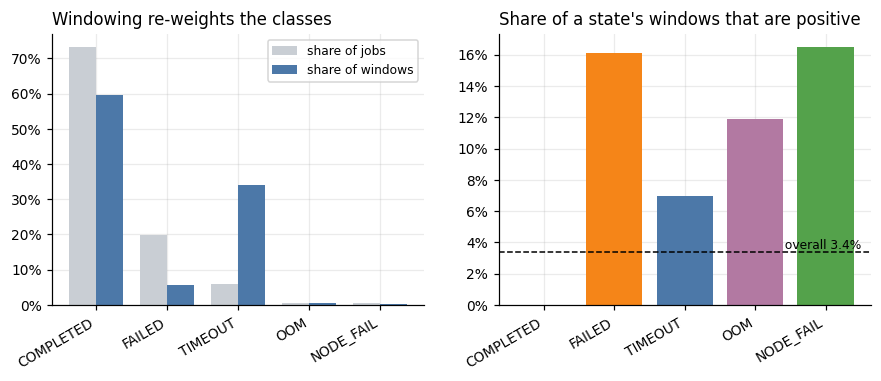

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
ax = axes[0]
share_jobs = jobs.state.value_counts(normalize=True).reindex(STATES)
share_win = census.windows / census.windows.sum()
x = np.arange(len(STATES)); w = 0.38
ax.bar(x - w/2, share_jobs.values, w, label="share of jobs", color="#c9ced4")
ax.bar(x + w/2, share_win.values, w, label="share of windows", color="#4c78a8")
ax.set_xticks(x, [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES], rotation=30, ha="right")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(fontsize=8); ax.set_title("Windowing re-weights the classes", loc="left")

ax = axes[1]
r = census.positive_rate.fillna(0)
ax.bar(range(len(r)), r.values, color=[COLOR[s] for s in r.index])
ax.axhline(W.y.mean(), color="k", ls="--", lw=1)
ax.text(len(r) - .5, W.y.mean(), f" overall {W.y.mean():.1%}", fontsize=8, va="bottom", ha="right")
ax.set_xticks(range(len(r)), [s.replace("OUT_OF_MEMORY", "OOM") for s in r.index],
              rotation=30, ha="right")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Share of a state's windows that are positive", loc="left")
save(fig, "10_window_census.png"); plt.show()

## 4. The ceiling imposed by shared nodes

Notebook 01 found that 78 % of snapshots are shared between concurrent jobs on
the same node, and that the telemetry attached to them is byte-identical. That
carries straight through to the windows: two co-tenant jobs produce windows with
identical features and possibly different labels.

One measurement trap here, worth stating because it is easy to fall into.
Matching the *kept* windows against each other -- looking for two rows with the
same `(node, t_end)` -- badly undercounts. With `STRIDE = 10` two co-tenant jobs
whose series began at different offsets almost never have a kept window ending on
the same timestamp, so the collisions are invisible even though the jobs are
running side by side. Measured that way the sharing rate appears to be 16 %
rather than 78 %, purely as an artefact of the subsampling.

So we measure concurrency on the **snapshot grid**, where it is exact, and then
read it off at the window level.

In [11]:
# Identify the physical telemetry row each snapshot came from: one row per
# (node, timestamp), shared by every job running there at that moment.
row_key = (ts_ns // 1_000_000_000) * 64 + keys.node.cat.codes.to_numpy().astype(np.int64)
_, inv = np.unique(row_key, return_inverse=True)
n_at_row   = np.bincount(inv).astype(np.int32)[inv]                    # jobs on this row
pos_at_row = np.bincount(inv, weights=snap_pos).astype(np.int32)[inv]  # of which positive

yv = W.y.to_numpy()
P = int(yv.sum())
others     = n_at_row[last] - 1                    # co-tenants when the warning would fire
others_pos = pos_at_row[last] - snap_pos[last]
shared     = others > 0
contra_pos = (yv == 1) & (others - others_pos > 0)
contra_neg = (yv == 0) & (others_pos > 0)

print(f"distinct telemetry rows: {inv.max() + 1:,} for {len(keys):,} snapshots")
print()
print("measured at the window's final snapshot - the moment a warning would fire")
print(f"  windows whose feature row is shared with another job: {shared.mean():>7.1%}")
print(f"  positive windows with a NON-failing co-tenant       : {int(contra_pos.sum()):>7,} "
      f"of {P:,} ({contra_pos.sum()/P:.1%})")
print(f"  negative windows with a FAILING co-tenant           : {int(contra_neg.sum()):>7,} "
      f"({contra_neg.mean():.2%} of all windows)")

# Stricter: require the co-tenant to be present for all 40 snapshots, so the two
# jobs share the entire feature vector rather than only its last row.
min_conc = np.lib.stride_tricks.sliding_window_view(n_at_row, WINDOW).min(axis=1)[starts]
min_neg = np.lib.stride_tricks.sliding_window_view(
    n_at_row - pos_at_row, WINDOW).min(axis=1)[starts]
print()
print("requiring the co-tenant to be present for the whole 20-minute window")
print(f"  windows sharing their entire feature vector         : {(min_conc > 1).mean():>7.1%}")
print(f"  positive windows whose identical twin is negative   : "
      f"{((yv == 1) & (min_neg > 0)).sum()/P:>7.1%}")

ex_q = W.nodetypes.isin(["gpu", "gpu_titanrtx"]).to_numpy()
print()
print(f"exclusive queues: {int(ex_q.sum()):,} windows ({ex_q.mean():.1%}), "
      f"positive rate {yv[ex_q].mean():.2%}, shared rows {shared[ex_q].mean():.1%}")
CEILING = 1 - contra_pos.sum() / P
print()
print(f"=> recall ceiling from node-level features: about {CEILING:.0%}")

distinct telemetry rows: 5,392,404 for 11,144,842 snapshots

measured at the window's final snapshot - the moment a warning would fire
  windows whose feature row is shared with another job:   78.2%
  positive windows with a NON-failing co-tenant       :  19,976 of 35,665 (56.0%)
  negative windows with a FAILING co-tenant           :  35,973 (3.40% of all windows)



requiring the co-tenant to be present for the whole 20-minute window
  windows sharing their entire feature vector         :   77.5%
  positive windows whose identical twin is negative   :   54.3%

exclusive queues: 100,135 windows (9.5%), positive rate 3.09%, shared rows 0.0%

=> recall ceiling from node-level features: about 44%


About **56 % of positive windows** carry a feature row that also belongs to a job
which is not failing, and for 54 % that co-tenant is present for the entire
20-minute window -- the two jobs are handed the same 56 numbers and given
opposite labels. A classifier that answers deterministically from those features
must be wrong on one of them.

That puts a ceiling near **44 %** on recall, set by the data rather than by the
algorithm. The 3.4 % of negative windows that sit next to a failing co-tenant are
the mirror image: they look exactly like positives, so they cap precision too.

The exclusive queues (`gpu`, `gpu_titanrtx`) are the exception. There one job
owns the node, the label is fully determined by the features, and the technique
is well posed -- at the cost of only ~10 % of the windows.

## 5. Box plots per label

This is the view suggested by the professor: for every metric, the distribution
of each of the four aggregations, split by the job's final state.

How to read them:

- boxes span the interquartile range, whiskers the 5th to 95th percentile, and
  outliers are hidden -- with a million windows the outlier cloud would hide the
  boxes;
- a **log scale** is used automatically where a metric spans orders of magnitude;
- the count above each box is how many windows it summarises, which matters
  because OOM and NODE_FAIL have three orders of magnitude fewer windows than
  COMPLETED.

What we are looking for is any panel where a failure state's box sits clear of
the COMPLETED box. That is what a model would have to exploit.

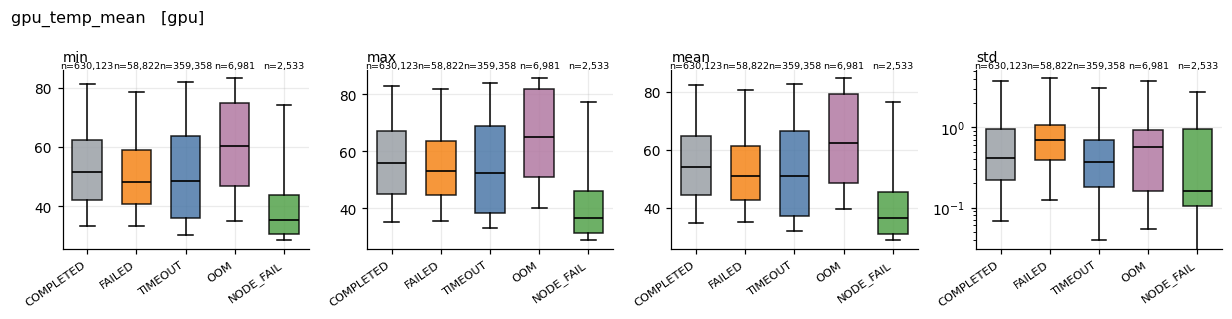

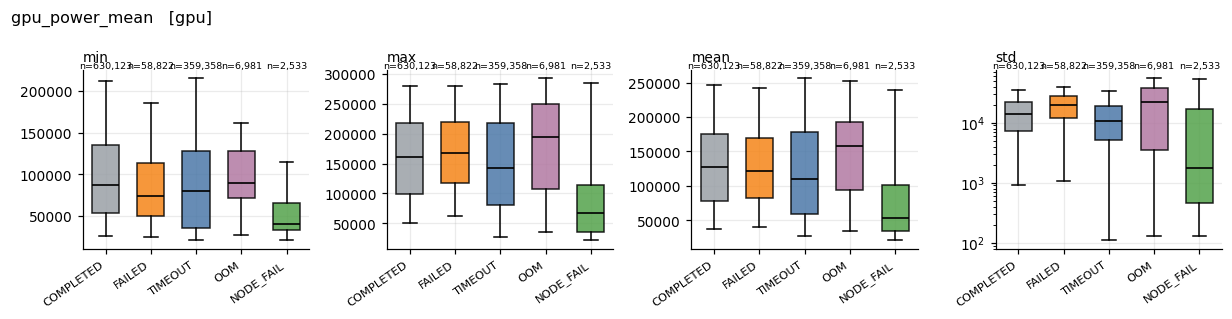

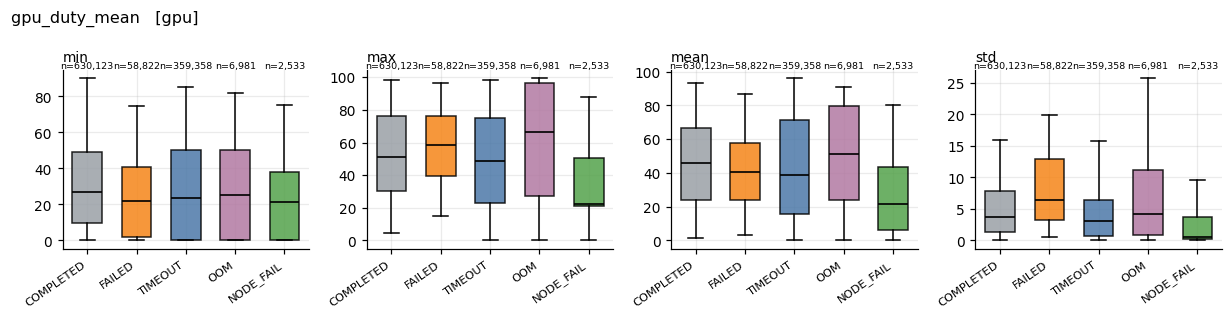

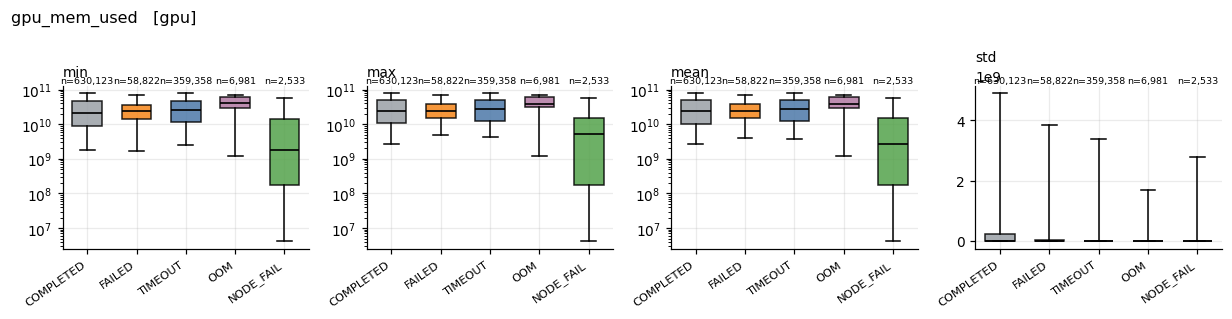

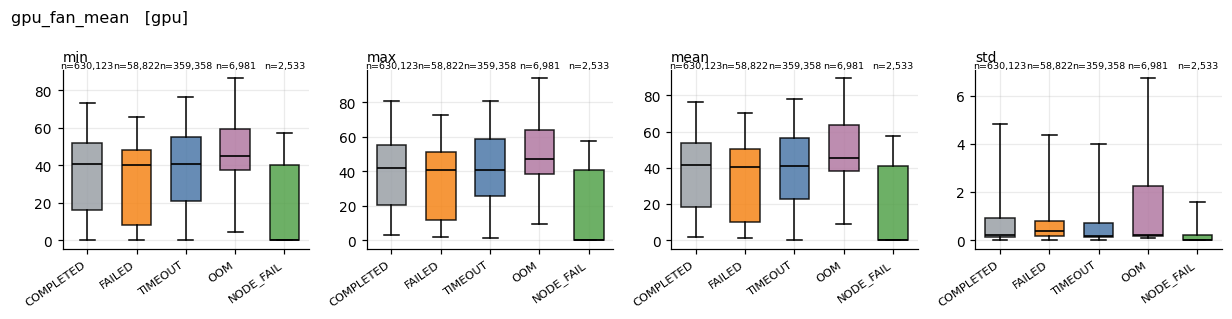

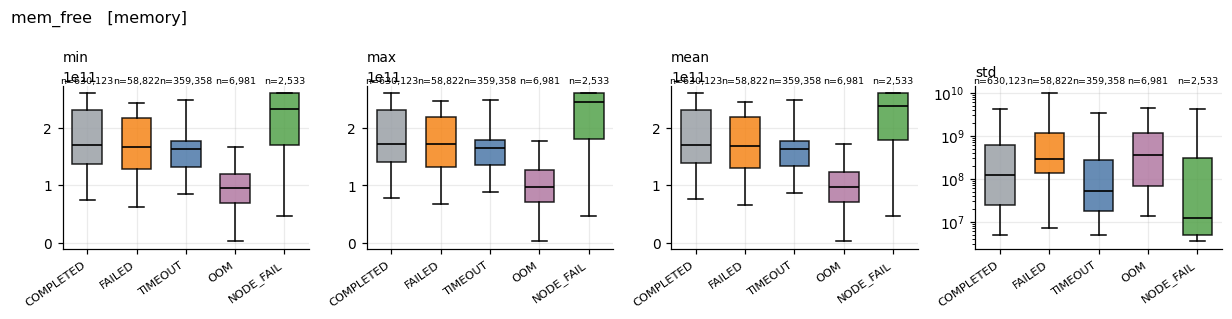

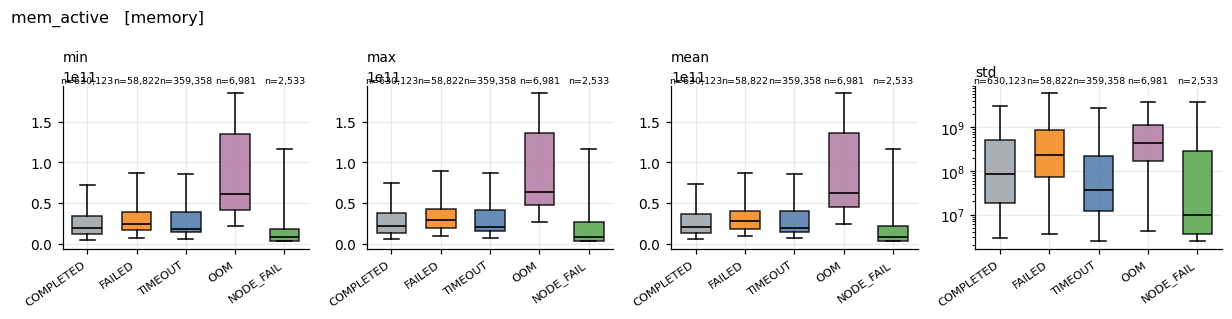

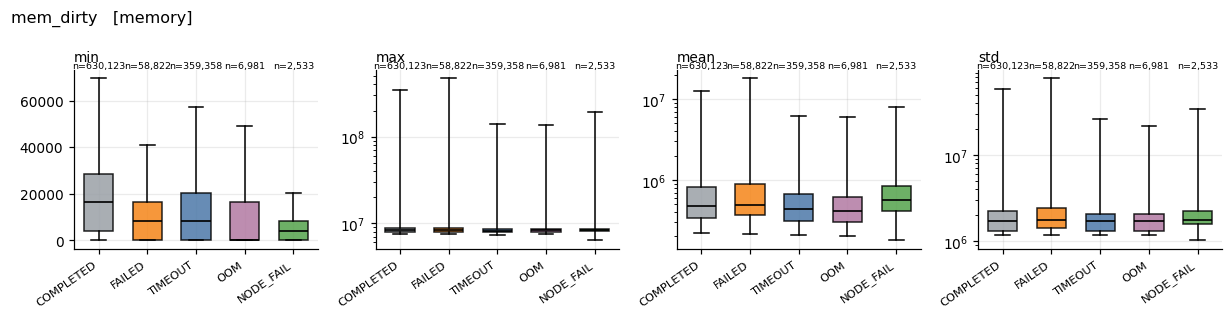

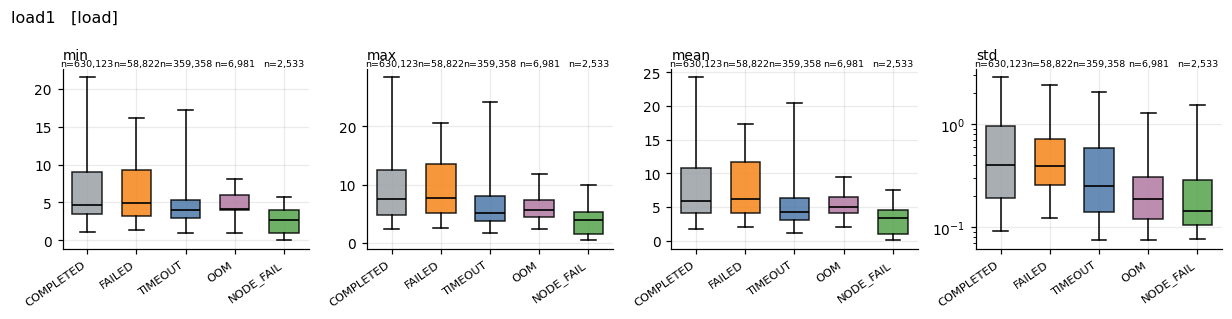

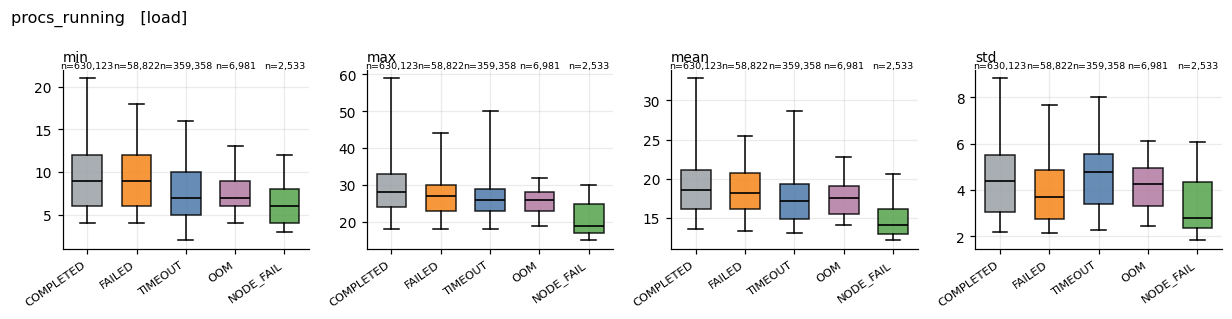

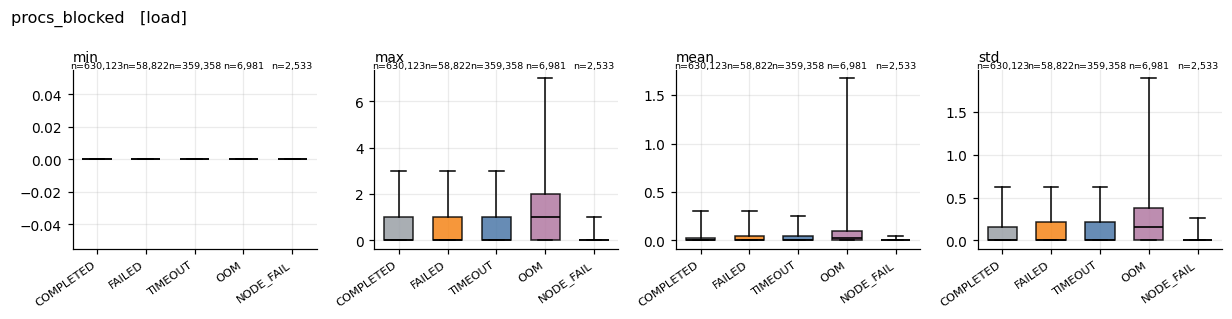

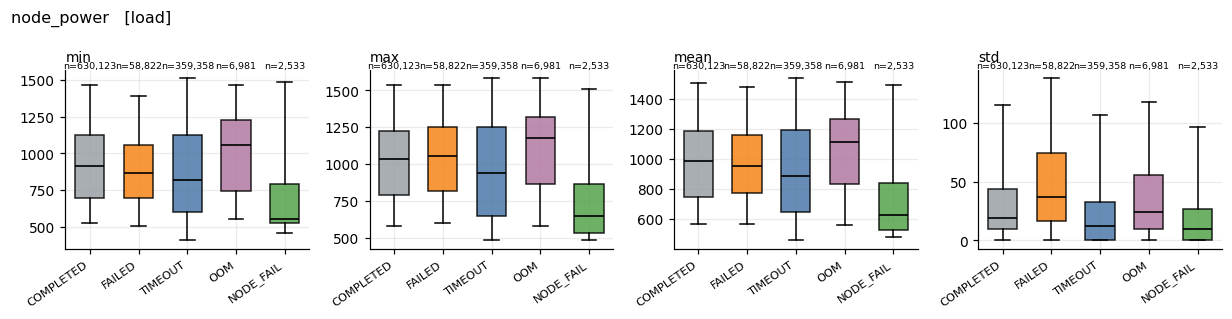

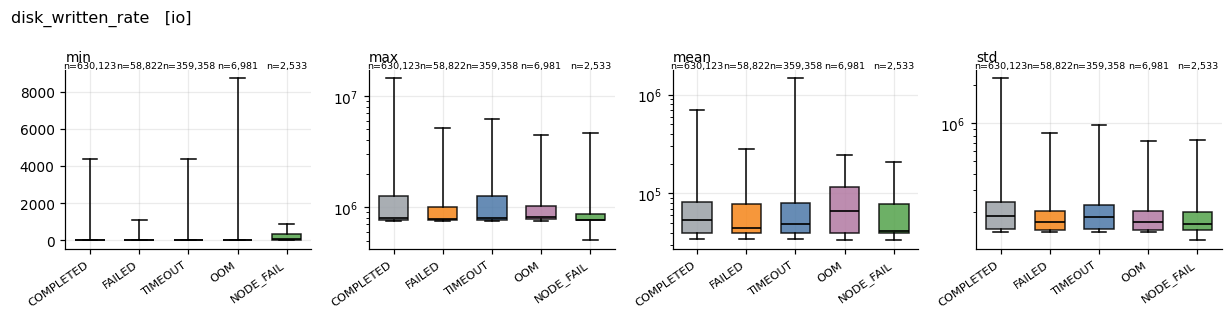

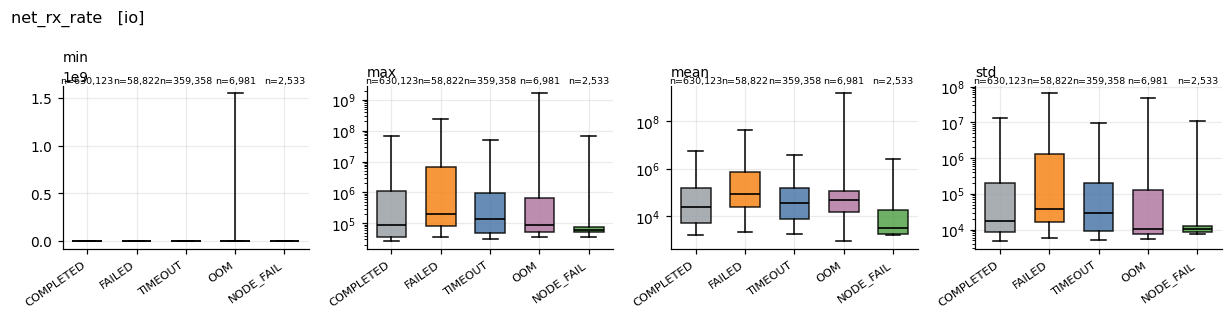

In [12]:
def boxplot_metric(metric, by="state"):
    """4 panels (min/max/mean/std) for one metric, grouped by state or by label."""
    if by == "state":
        groups = [(s, W.state == s) for s in STATES]
        labels = [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES]
        colors = [COLOR[s] for s in STATES]
    else:
        groups = [("negative", W.y == 0), ("positive", W.y == 1)]
        labels = ["window label 0", "window label 1"]
        colors = ["#c9ced4", "#e45756"]

    fig, axes = plt.subplots(1, 4, figsize=(11.2, 2.9))
    for ax, agg in zip(axes, AGGS):
        col = W[f"{metric}__{agg}"].to_numpy()
        data = [col[m.to_numpy()] for _, m in groups]
        bp = ax.boxplot(data, whis=(5, 95), showfliers=False, patch_artist=True,
                        medianprops=dict(color="black", lw=1.1), widths=0.6)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.85)
        ax.set_xticks(range(1, len(data) + 1), labels, rotation=35, ha="right", fontsize=7.5)
        ax.set_title(agg, loc="left", fontsize=9)
        # log scale only when it helps and is legal
        flat = col[np.isfinite(col)]
        pos = flat[flat > 0]
        if len(pos) > 0.9 * len(flat) and pos.max() / max(np.percentile(pos, 1), 1e-12) > 500:
            ax.set_yscale("log")
        if by == "state":
            top = ax.get_ylim()[1]
            for i, d in enumerate(data, start=1):
                ax.text(i, top, f"n={len(d):,}", ha="center", va="bottom", fontsize=6.2,
                        rotation=0)
    fig.suptitle(f"{metric}   [{GROUP[metric]}]", x=0.005, ha="left", fontsize=10.5)
    fig.tight_layout()
    return fig

for m in METRICS:
    fig = boxplot_metric(m)
    save(fig, f"box_{m}.png")
    plt.show()

Most panels show the failure boxes sitting on top of the COMPLETED box. That is
the honest headline of this section: **at the level of a single aggregated
metric, the classes overlap almost completely.** The separation a model finds is
not visible here, which is exactly why a model is needed -- and also why its
scores are modest.

A few panels do separate. The next two cells rank all 56 features so we do not
have to judge that by eye.

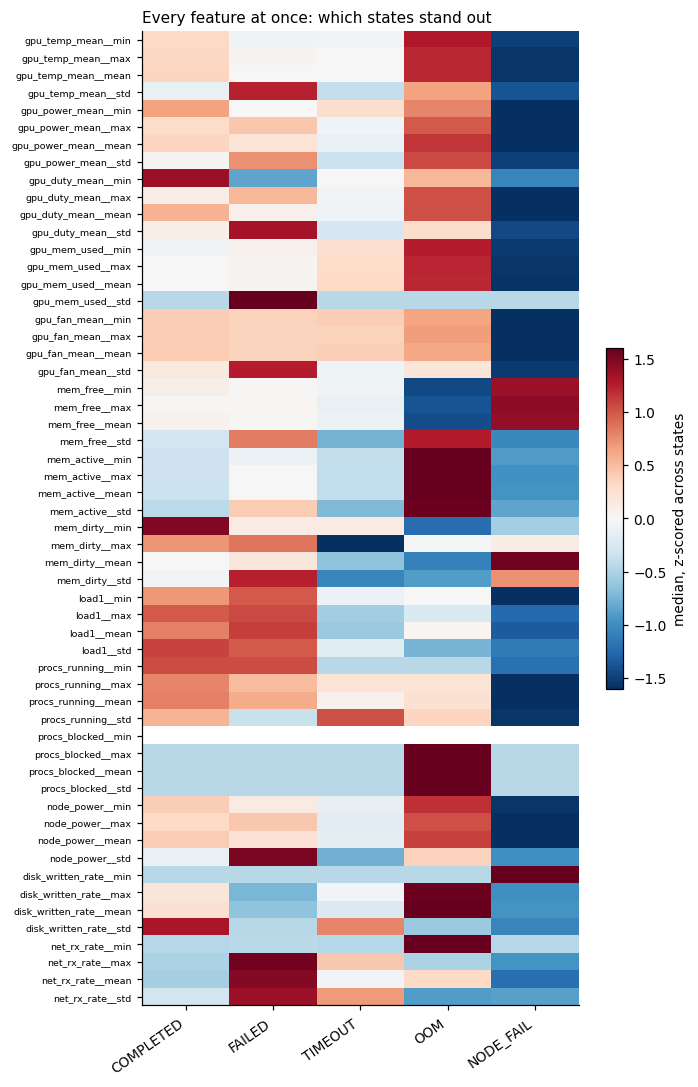

In [13]:
# One overview instead of 14 figures: the median of each feature per state,
# z-scored across states so that unlike units can share a colour scale.
med = W.groupby("state", observed=True)[FEATURES].median().reindex(STATES)
z = ((med - med.mean()) / med.std().replace(0, np.nan)).T

fig, ax = plt.subplots(figsize=(6.4, 11.5))
im = ax.imshow(z.values, aspect="auto", cmap="RdBu_r", vmin=-1.6, vmax=1.6)
ax.set_xticks(range(len(STATES)), [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES],
              rotation=35, ha="right")
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=6.2)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.35, label="median, z-scored across states")
ax.set_title("Every feature at once: which states stand out", loc="left", fontsize=10)
save(fig, "11_feature_overview.png"); plt.show()

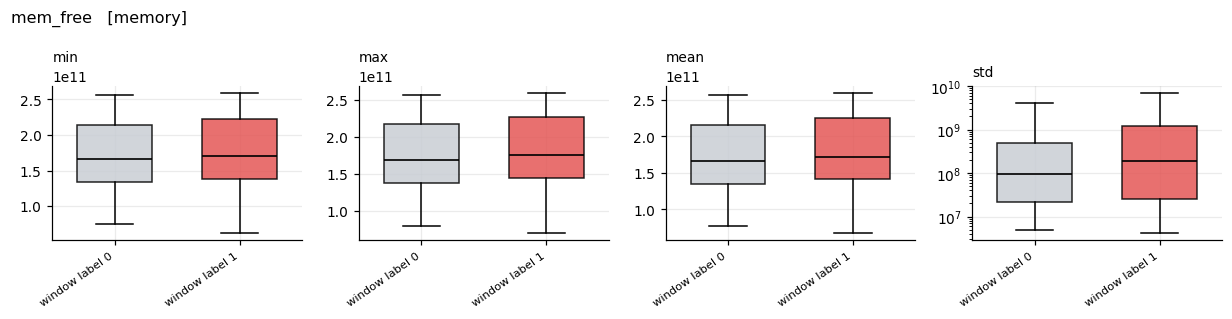

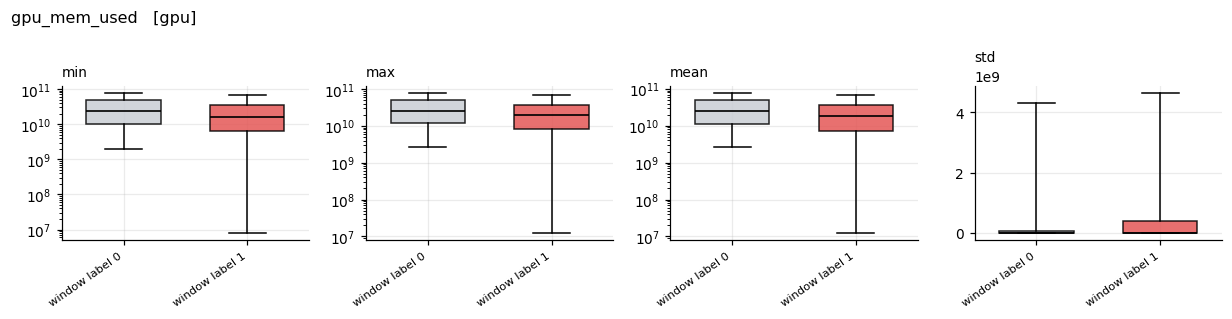

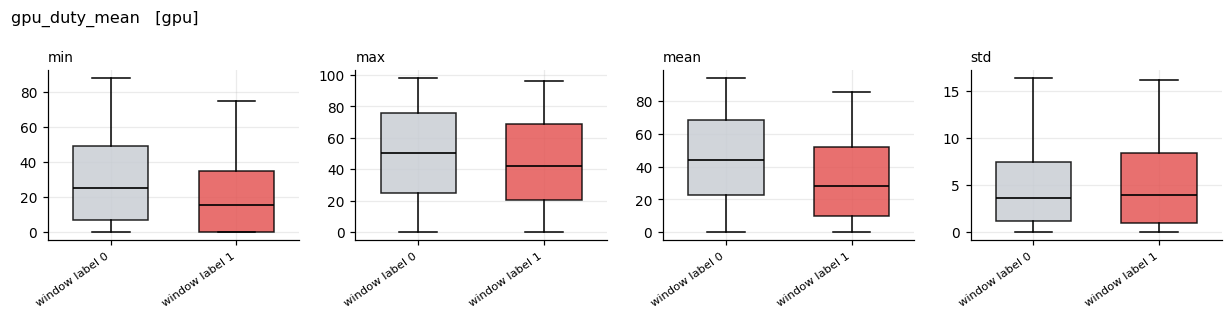

In [14]:
for m in ["mem_free", "gpu_mem_used", "gpu_duty_mean"]:
    fig = boxplot_metric(m, by="label")
    save(fig, f"box_bylabel_{m}.png")
    plt.show()

## 6. Which features actually separate the classes?

A box plot is a summary; the question underneath it is how well a single feature
would rank positives above negatives. That is exactly the area under the ROC
curve for that one feature, and it can be computed from ranks without training
anything.

`AUC = 0.5` means the feature is useless. We report `|AUC - 0.5|` so that a
feature which is informative in the negative direction (lower is riskier) ranks
alongside one that is informative in the positive direction.

scored on 300,000 sampled windows (10,249 positive)


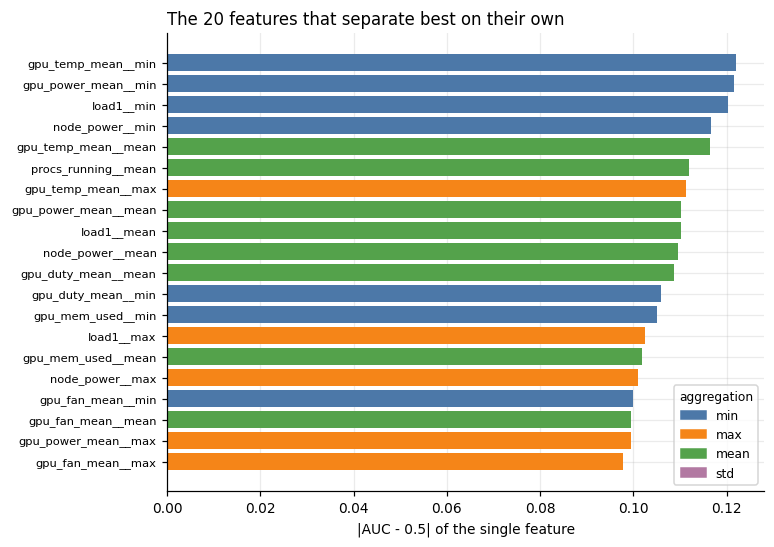


mean |AUC-0.5| by aggregation:
mean    0.071311
min     0.070278
max     0.069213
std     0.030685

mean |AUC-0.5| by metric group:
gpu       0.084753
load      0.067814
io        0.034388
memory    0.027136


In [15]:
from scipy.stats import rankdata

rng = np.random.default_rng(42)
idx = rng.choice(len(W), size=min(300_000, len(W)), replace=False)
ys = W.y.to_numpy()[idx]
n_pos, n_neg = int(ys.sum()), int((1 - ys).sum())
print(f"scored on {len(idx):,} sampled windows ({n_pos:,} positive)")

auc = {}
for f in FEATURES:
    r = rankdata(W[f].to_numpy()[idx])
    auc[f] = (r[ys == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
auc = pd.Series(auc)
sep = (auc - 0.5).abs().sort_values(ascending=False)

top = sep.head(20)[::-1]
fig, ax = plt.subplots(figsize=(7.0, 5.4))
from matplotlib.patches import Patch
AGG_COLOR = {"min": "#4c78a8", "max": "#f58518", "mean": "#54a24b", "std": "#b279a2"}
ax.barh(range(len(top)), top.values,
        color=[AGG_COLOR[f.split("__")[1]] for f in top.index])
ax.set_yticks(range(len(top)), top.index, fontsize=7.5)
ax.set_xlabel("|AUC - 0.5| of the single feature")
handles = [Patch(color=c, label=a) for a, c in AGG_COLOR.items()]
ax.legend(handles=handles, fontsize=8, title="aggregation", title_fontsize=8)
ax.set_title("The 20 features that separate best on their own", loc="left")
save(fig, "12_separability.png"); plt.show()

print("\nmean |AUC-0.5| by aggregation:")
print(sep.groupby([f.split("__")[1] for f in sep.index]).mean().sort_values(
    ascending=False).to_string())
print("\nmean |AUC-0.5| by metric group:")
print(sep.groupby([GROUP[f.split("__")[0]] for f in sep.index]).mean().sort_values(
    ascending=False).to_string())

## 7. How much do the 56 features duplicate each other?

Fifty-six columns is not fifty-six independent pieces of evidence. `min`, `max`
and `mean` of a slowly-varying metric are nearly the same number, and several
metrics move together because they all reflect how busy the node is.

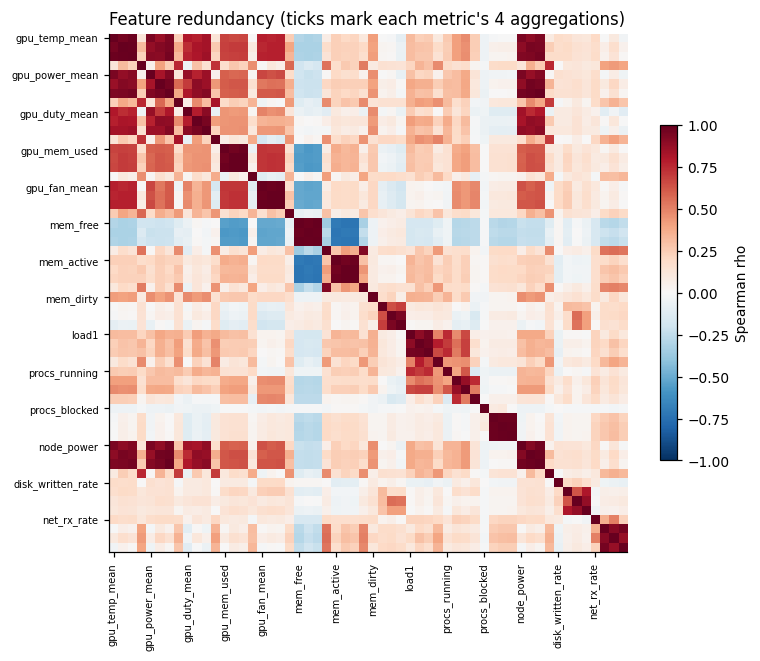

features with |rho| > 0.95 against at least one other: 30 of 56
mean |rho| between the 4 aggregations of the same metric: 0.59


In [16]:
sub = W[FEATURES].to_numpy()[rng.choice(len(W), size=50_000, replace=False)]
ranks = np.apply_along_axis(rankdata, 0, sub)
C = np.corrcoef(ranks, rowvar=False)          # Spearman

fig, ax = plt.subplots(figsize=(7.6, 6.6))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(0, len(FEATURES), 4),
              [FEATURES[i].split("__")[0] for i in range(0, len(FEATURES), 4)],
              rotation=90, fontsize=6.5)
ax.set_yticks(range(0, len(FEATURES), 4),
              [FEATURES[i].split("__")[0] for i in range(0, len(FEATURES), 4)], fontsize=6.5)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.6, label="Spearman rho")
ax.set_title("Feature redundancy (ticks mark each metric's 4 aggregations)", loc="left")
save(fig, "13_redundancy.png"); plt.show()

off = C - np.eye(len(C))
near_dup = (np.abs(off) > 0.95).any(axis=1)
print(f"features with |rho| > 0.95 against at least one other: "
      f"{int(near_dup.sum())} of {len(FEATURES)}")
print(f"mean |rho| between the 4 aggregations of the same metric: "
      f"{np.mean([abs(C[i, j]) for m in range(len(METRICS)) for i in range(4*m, 4*m+4) for j in range(4*m, 4*m+4) if i != j]):.2f}")

## 8. Is there a precursor at all?

The premise of the whole project is that a failing job looks different shortly
before it ends. This cell tests that premise directly, without a model: for the
most separable metrics, plot the median value as a function of **how long is left
until the job ends**, one line per state.

Values are standardised per node first (subtract the node's median, divide by its
IQR), because nodes differ in absolute level and we care about the shape of the
trajectory, not the offset.

metrics plotted: ['gpu_temp_mean', 'gpu_power_mean', 'load1', 'node_power', 'procs_running', 'gpu_duty_mean']


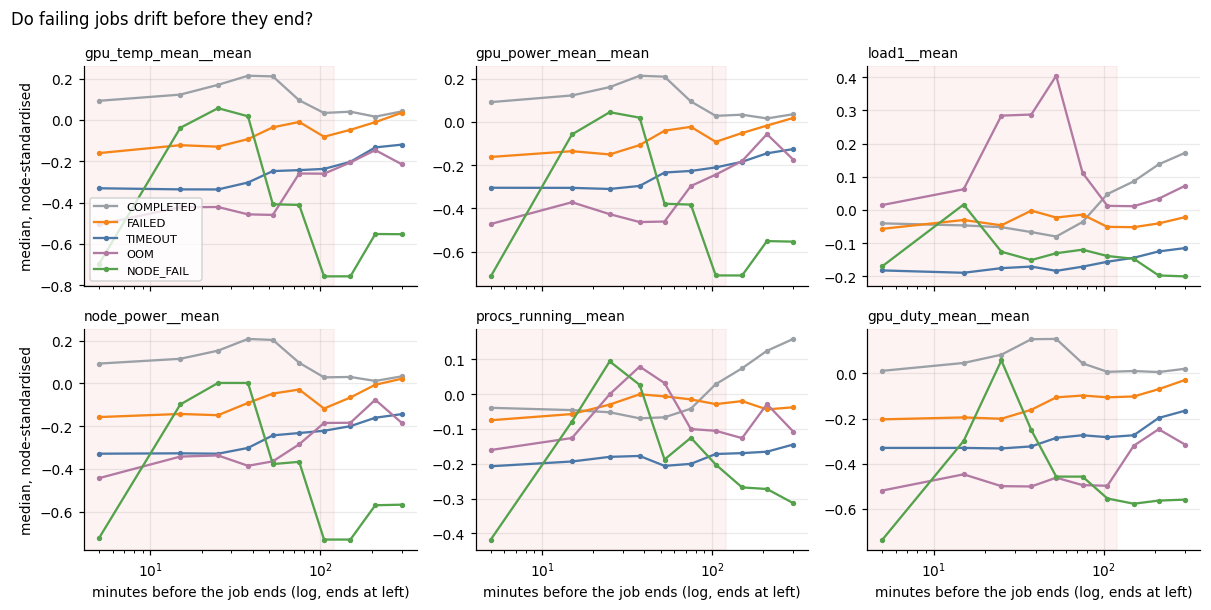

In [17]:
best_metrics = list(dict.fromkeys(f.split("__")[0] for f in sep.index))[:6]
print("metrics plotted:", best_metrics)

edges = np.array([0, 10, 20, 30, 45, 60, 90, 120, 180, 240, 360]) * 60   # seconds
centres = (edges[:-1] + edges[1:]) / 2 / 60
bin_id = np.digitize(W.ttf_end.to_numpy(), edges) - 1

fig, axes = plt.subplots(2, 3, figsize=(11.0, 5.6), sharex=True)
for ax, m in zip(axes.ravel(), best_metrics):
    col = f"{m}__mean"
    v = W[col].to_numpy().astype(np.float64)
    nid = W.node.astype(str).to_numpy()
    df = pd.DataFrame({"v": v, "n": nid})
    med = df.groupby("n").v.transform("median")
    iqr = df.groupby("n").v.transform(lambda s: s.quantile(.75) - s.quantile(.25))
    zv = (v - med.to_numpy()) / np.where(iqr.to_numpy() > 0, iqr.to_numpy(), 1.0)

    for s in STATES:
        msk = (W.state == s).to_numpy() & (bin_id >= 0) & (bin_id < len(centres))
        if msk.sum() < 200:
            continue
        prof = pd.Series(zv[msk]).groupby(bin_id[msk]).median()
        ax.plot(centres[prof.index], prof.values, color=COLOR[s], lw=1.5, marker="o",
                ms=2.5, label=s.replace("OUT_OF_MEMORY", "OOM"))
    ax.invert_xaxis(); ax.set_xscale("log")
    ax.set_title(col, loc="left", fontsize=9)
    ax.axvspan(0, HORIZON_H * 60, color="#e45756", alpha=0.07)
axes[0, 0].legend(fontsize=7.5)
for ax in axes[-1]:
    ax.set_xlabel("minutes before the job ends (log, ends at left)")
for ax in axes[:, 0]:
    ax.set_ylabel("median, node-standardised")
fig.suptitle("Do failing jobs drift before they end?", x=0.005, ha="left")
fig.tight_layout()
save(fig, "14_precursors.png"); plt.show()

Read the shaded band on the right of each panel: that is the 2-hour horizon, the
region we label positive. A precursor exists only where a failure line separates
from the grey COMPLETED line *and* keeps moving as the end approaches.

## 9. Why a 2-hour horizon?

The horizon is a free parameter. Because every window stores `ttf_end`, the
number of seconds from its last snapshot to the job's end, we can recompute the
label for any horizon in closed form -- no rebuild.

The window's 40 snapshots sit on an even 30-second grid (guaranteed by the gap
rule), so the `j`-th snapshot counted back from the end is exactly `j * 30 s`
further from the job's end. Counting how many of them fall inside a horizon is
then arithmetic.

In [18]:
def relabel(ttf_end, state, horizon_h, window=WINDOW, snap_s=SNAP_S,
            positive_states=FAILURE_STATES):
    """Window labels for any horizon, computed from ttf_end alone."""
    ttf = np.asarray(ttf_end, dtype=np.float64)
    j_hi = np.floor((horizon_h * 3600 - ttf) / snap_s)     # last snapshot inside horizon
    j_lo = np.ceil(np.maximum(0.0, -ttf) / snap_s)         # first snapshot with ttf >= 0
    n_in = np.clip(j_hi - j_lo + 1.0, 0.0, float(window))
    return ((n_in >= window / 2) & pd.Series(state).isin(positive_states).to_numpy()).astype(np.int8)

check = relabel(W.ttf_end, W.state, HORIZON_H)
agree = (check == W.y.to_numpy()).mean()
print(f"closed-form relabel reproduces the built labels for {agree:.4%} of windows")
assert agree > 0.999, "the closed form disagrees with the labels built from snapshots"

rows = []
for h in (0.25, 0.5, 1.0, 2.0, 4.0, 6.0, 12.0):
    yh = relabel(W.ttf_end, W.state, h)
    row = {"horizon_h": h, "positives": int(yh.sum()), "positive_rate": yh.mean()}
    for s in FAILURE_STATES:
        row[s] = int(yh[(W.state == s).to_numpy()].sum())
    rows.append(row)
hz = pd.DataFrame(rows)
print()
print(hz.to_string(index=False, formatters={"positive_rate": "{:.2%}".format}))

closed-form relabel reproduces the built labels for 100.0000% of windows



 horizon_h  positives positive_rate  FAILED  TIMEOUT  OUT_OF_MEMORY  NODE_FAIL
      0.25       2731         0.26%     765     1885             56         25
      0.50       8439         0.80%    2515     5628            197         99
      1.00      18704         1.77%    5281    12742            436        245
      2.00      35665         3.37%    9491    24926            830        418
      4.00      62020         5.86%   15774    44250           1337        659
      6.00      84085         7.95%   20509    60945           1732        899
     12.00     140829        13.31%   31094   105646           2533       1556


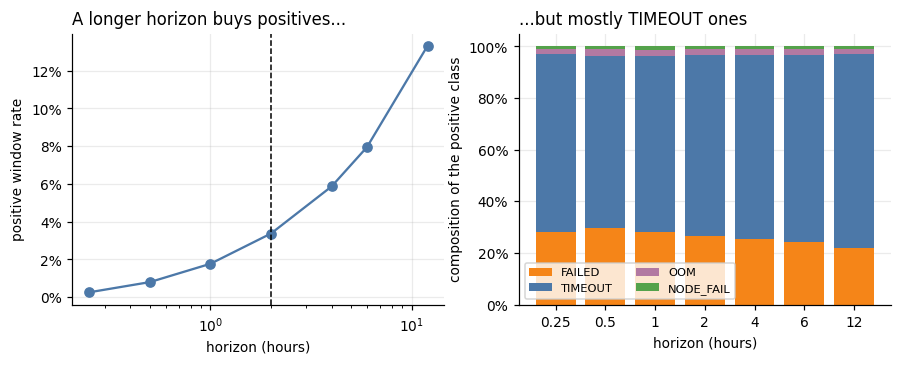

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
ax = axes[0]
ax.plot(hz.horizon_h, hz.positive_rate, marker="o", color="#4c78a8")
ax.axvline(HORIZON_H, color="k", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("horizon (hours)"); ax.set_ylabel("positive window rate")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("A longer horizon buys positives...", loc="left")

ax = axes[1]
bottom = np.zeros(len(hz))
for s in FAILURE_STATES:
    ax.bar(range(len(hz)), hz[s] / hz.positives, bottom=bottom, color=COLOR[s],
           label=s.replace("OUT_OF_MEMORY", "OOM"))
    bottom += (hz[s] / hz.positives).to_numpy()
ax.set_xticks(range(len(hz)), [f"{h:g}" for h in hz.horizon_h])
ax.set_xlabel("horizon (hours)"); ax.set_ylabel("composition of the positive class")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(fontsize=7.5, ncols=2)
ax.set_title("...but mostly TIMEOUT ones", loc="left")
save(fig, "15_horizon.png"); plt.show()

Widening the horizon does raise the positive rate, but it does so by adding
TIMEOUT windows -- long jobs have many windows inside any horizon, short ones
have none. Beyond a few hours the positive class is essentially "a long job that
will hit its walltime", which is a different prediction problem from node health.

Two hours is a reasonable compromise: enough positives to train on, still short
enough that a warning would be actionable.

## 10. Summary

In [20]:
facts = {
    "windows built": f"{len(W):,}",
    "features per window": f"{len(FEATURES)} ({len(METRICS)} metrics x {len(AGGS)} aggs)",
    "jobs represented": f"{W.slurm_id.nunique():,} of {len(jobs):,}",
    "window positive rate": f"{W.y.mean():.2%}",
    "positive rate, train / test": f"{W[W.split=='train'].y.mean():.2%} / {W[W.split=='test'].y.mean():.2%}",
    "windows discarded for spanning a gap":
        f"{int(same_series.sum() - (same_series & (max_gap <= GAP_TOL_S)).sum()):,}",
    "windows sharing their feature row with another job": f"{shared.mean():.1%}",
    "positive windows contradicted by a co-tenant": f"{contra_pos.sum()/P:.1%}",
    "recall ceiling from node-level features": f"{CEILING:.0%}",
    "best single-feature |AUC-0.5|": f"{sep.iloc[0]:.3f} ({sep.index[0]})",
    "median single-feature |AUC-0.5|": f"{sep.median():.3f}",
    "features with |rho|>0.95 to another": f"{int(near_dup.sum())} of {len(FEATURES)}",
}
for k, v in facts.items():
    print(f"  {k:<45} {v}")
json.dump(facts, open(DATA / "facts_02.json", "w"), indent=2)

  windows built                                 1,057,817
  features per window                           56 (14 metrics x 4 aggs)
  jobs represented                              12,959 of 23,618
  window positive rate                          3.37%
  positive rate, train / test                   3.26% / 4.09%
  windows discarded for spanning a gap          22,754
  windows sharing their feature row with another job 78.2%
  positive windows contradicted by a co-tenant  56.0%
  recall ceiling from node-level features       44%
  best single-feature |AUC-0.5|                 0.122 (gpu_temp_mean__min)
  median single-feature |AUC-0.5|               0.053
  features with |rho|>0.95 to another           30 of 56


### What this notebook establishes

1. **The rows exist and the mechanics are sound.** About a million windows, 3 %
   of them positive, every one gap-free and confined to a single job on a single
   node, with labels that the closed-form horizon formula reproduces exactly.

2. **No single feature separates the classes.** The best of the 56 reaches an AUC
   only modestly away from 0.5, and the box plots overlap almost everywhere. Any
   signal here is weak and multivariate.

3. **The features are highly redundant.** Four aggregations of a slowly-varying
   metric are close to one number.

4. **The ceiling from notebook 01 survives windowing.** 56 % of positive windows
   share their feature row with a co-tenant job that does not fail, which caps
   recall near 44 % regardless of the model. Only the exclusive queues escape it.

Notebook 03 turns these properties into a statement about which use case this
pipeline can serve.